Executar esses comandos no terminal antes de rodar os códigos:
* python -m venv venv
* .\venv\Scripts\Activate.ps1 
* pip install pandas numpy scikit-learn ipykernel  
* pip install tabulate

# Preparação dos Dados (Pré-processamento) 

In [38]:
# ==========================================
# ETAPA 1: PREPARAÇÃO DO AMBIENTE E CARGA
# ==========================================

# Importamos as bibliotecas principais:
# Pandas: Essencial para manipulação e análise de dados em tabelas (DataFrames).
# OS: Usada para navegar e verificar pastas e arquivos no sistema operacional.
import pandas as pd
import numpy as np
import os

# Lista os arquivos dentro da pasta 'data' para confirmar que o dataset está acessível
print(os.listdir("../data"))

# Importamos recursos específicos do Scikit-Learn:
# train_test_split: Para separar os dados em conjuntos de treino e teste.
# MinMaxScaler: Para normalizar as notas (rating) em uma escala comum (0 a 1).
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# --- VERIFICAÇÃO DE SEGURANÇA ---x
# Antes de carregar, checamos se a pasta com o dataset (MovieLens 1M) está visível.
# Isso garante que o caminho relativo ('data/') está correto em relação ao script.
if os.path.exists("../data"):
    print("Pasta de dados encontrada!")
    print("Arquivos disponíveis:", os.listdir("../data"))
else:
    print("ERRO: A pasta '../data' não foi encontrada no local atual.")

# --- CARREGAMENTO DOS DADOS ---
# Lemos o arquivo 'ratings.dat'.
# Definimos nomes manuais para as colunas, pois o arquivo original não possui cabeçalho.
df = pd.read_csv(
    "../data/ratings.dat",
    sep="::",
    engine="python",
    names=["userId", "movieId", "rating", "timestamp"]
)

# Exibe as 5 primeiras linhas para validar se a leitura foi feita corretamente
df.head()

['movies.dat', 'ratings.dat', 'README', 'users.dat']
Pasta de dados encontrada!
Arquivos disponíveis: ['movies.dat', 'ratings.dat', 'README', 'users.dat']


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [39]:
# =========================================================
# ETAPA 2: EXPLORAÇÃO E AUDITORIA DE QUALIDADE
# =========================================================

# Ajustamos a configuração do Pandas para que números grandes e decimais
# sejam exibidos de forma legível, evitando a notação científica (ex: e+06).
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("--- INFORMAÇÕES TÉCNICAS ---")
# O .info() nos dá o "raio-X" do DataFrame:
# 1. Total de entradas (1.000.209)
# 2. Se as colunas são reconhecidas como números (int64/float64)
# 3. O uso de memória do sistema
print(f"[!] O dataset possui 1.000.209 linhas, 4 colunas, não existem valores nulos (non-null) e todos os dados são numéricos (int64)\n")
df.info()

print(f"\n--- LIMPEZA DE DADOS ---")
# Verificamos se existem "buracos" no dataset. 
# Esperamos 0 em todas as colunas, o que significa que o dataset está completo.

print(f"Valores ausentes: {df['userId'].isnull().sum()}")
# Verificamos se existem linhas idênticas repetidas.
# Dados duplicados podem "viciar" a IA (Overfitting), por isso o ideal é que o resultado seja 0.
print(f"Registros duplicados: {df.duplicated().sum()}")
# Se ambos forem zero, o dataset é considerado "saudável" para o treinamento.

--- INFORMAÇÕES TÉCNICAS ---
[!] O dataset possui 1.000.209 linhas, 4 colunas, não existem valores nulos (non-null) e todos os dados são numéricos (int64)

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1000209 non-null  int64
 1   movieId    1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB

--- LIMPEZA DE DADOS ---
Valores ausentes: 0
Registros duplicados: 0


In [40]:
# =========================================================
# ETAPA 3: NORMALIZAÇÃO E VALIDAÇÃO ESTATÍSTICA
# =========================================================

# Inicializamos o MinMaxScaler:
# Este recurso reescala os dados para que o menor valor vire 0 e o maior vire 1.    
scaler = MinMaxScaler()

# Aplicamos a normalização na coluna 'rating' (notas de 1 a 5).
# Criamos a nova coluna 'rating_normalizado' para manter o dado original intacto.
df['rating_normalizado'] = scaler.fit_transform(df[['rating']])

print(f"[!] As notas originais vão de: 1 até 5. A normalização transforma para: 0 até 1\n")

# # Exibe as primeiras linhas para conferir a nova coluna lado a lado com a original
df.head()

[!] As notas originais vão de: 1 até 5. A normalização transforma para: 0 até 1



,userId,movieId,rating,timestamp,rating_normalizado
0,1,1193,5,978300760,1.00
1,1,661,3,978302109,0.50
2,1,914,3,978301968,0.50
3,1,3408,4,978300275,0.75
4,1,2355,5,978824291,1.00


In [41]:
print(f"\n--- RESUMO DA ESTATÍSTICA ---")
# Exibe o volume total formatado com pontos (padrão brasileiro)
print(f"Total de avaliações: {df.shape[0]:,}".replace(',', '.'))
# Mostra a tendência central das notas dos usuários
print(f"Média das notas originais: {df['rating'].mean():.2f}")
# Prova real de que a normalização atingiu os limites de 0 e 1
print(f"Variação após a normalização: {df['rating_normalizado'].min():.0f} até {df['rating_normalizado'].max():.0f}")

print(f"\nNota: A normalização (0 a 1) foi concluída com sucesso, permitindo que o modelo trate as notas de forma equilibrada.")
print("não dê peso excessivo a notas altas, tratando a variação de forma equilibrada.")

print(f"\n--- ESTATÍSTICA DESCRITIVA ---")
# O comando .describe() gera métricas como desvio padrão e quartis.
# Usamos o .T (transpor) para inverter a tabela, facilitando a leitura das colunas.
df.describe().T


--- RESUMO DA ESTATÍSTICA ---
Total de avaliações: 1.000.209
Média das notas originais: 3.58
Variação após a normalização: 0 até 1

Nota: A normalização (0 a 1) foi concluída com sucesso, permitindo que o modelo trate as notas de forma equilibrada.
não dê peso excessivo a notas altas, tratando a variação de forma equilibrada.

--- ESTATÍSTICA DESCRITIVA ---


,count,mean,std,min,25%,50%,75%,max
userId,1000209.00,3024.51,1728.41,1.00,1506.00,3070.00,4476.00,6040.00
movieId,1000209.00,1865.54,1096.04,1.00,1030.00,1835.00,2770.00,3952.00
rating,1000209.00,3.58,1.12,1.00,3.00,4.00,4.00,5.00
timestamp,1000209.00,972243695.40,12152558.94,956703932.00,965302637.00,973018006.00,975220939.00,1046454590.00
rating_normalizado,1000209.00,0.65,0.28,0.00,0.50,0.75,0.75,1.00


In [42]:
# =========================================================
# ETAPA 4: DIVISÃO DE TREINO E TESTE
# =========================================================

# Definimos as variáveis do modelo:
# X (Entradas/Features): Usamos as IDs de usuário e filme para a recomendação.
# y (Alvo/Target): É o valor que queremos prever (a nota normalizada).
x = df[['userId', 'movieId']]
y = df['rating_normalizado']

# Realizamos o "Split" dos dados:
# test_size=0.2: Reservamos 20% do dataset para testar a IA com dados inéditos.
# random_state=42: Garante que a divisão seja sempre a mesma ao rodar o código, 
# facilitando a comparação de resultados entre a equipe.
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Exibe as dimensões dos conjuntos criados
# Espera-se ~800k linhas para treino e ~200k para teste.
print("Treino:", x_train.shape[0]) # o [0] é para printar apenas o valor de linhas, sem mostrar quantas colunas tem a tabela
print("Teste:", x_test.shape[0])

# Nota de Apresentação:
# X → Dados de entrada (Quem avaliou e Qual filme)
# y → O que queremos prever (A nota)
# 80% treino e 20% teste

Treino: 800167
Teste: 200042


# Refinamento do Modelo (SVD via Sckikit-learn)

In [43]:
# =========================================================
# ETAPA 1: TREINAMENTO E REFINAMENTO DO MODELO SVD
# =========================================================
from sklearn.decomposition import TruncatedSVD
import time

print("--- INICIANDO TREINAMENTO DO MODELO ---")
start_time = time.time()

# 1. RECONSTRUINDO O DATAFRAME APENAS COM DADOS DE TREINO
# Unimos x_train e y_train para montar a matriz sem vazamento de dados
df_train = x_train.copy()
df_train['rating_normalizado'] = y_train

medias_usuarios = df_train.groupby('userId')['rating_normalizado'].mean()

user_movie_matrix = df_train.pivot_table(
    index='userId', columns='movieId', values='rating_normalizado'
)
user_movie_matrix = user_movie_matrix.apply(
    lambda row: row.fillna(medias_usuarios[row.name]), axis=1
)

# 3. CONFIGURAÇÃO DO ALGORITMO
# Valores menores (ex: 20) perdiam muitos detalhes dos gostos apesar de ser mais rápido
# Valores maiores (ex: 300) aumentavam o custo computacional sem ganho real de precisão, perdendo capacidade de generalizar (Overfitting)
# Aumentar os componentes (n_components) melhora a precisão, mas exige mais CPU/RAM
n_componentes = 200
svd_model = TruncatedSVD(n_components=n_componentes, random_state=42)
matrix_svd = svd_model.fit_transform(user_movie_matrix)

duration = time.time() - start_time
variancia = svd_model.explained_variance_ratio_.sum()

print(f"✅ Modelo treinado em {duration:.2f} segundos.")
print(f"📊 Componentes Latentes: {n_componentes}")
print(f"📈 Variância Explicada Total: {variancia:.2%}")
print(f"⚠️  Data leakage corrigido: SVD treinado apenas com {x_train.shape[0]:,} avaliações de treino.")

--- INICIANDO TREINAMENTO DO MODELO ---
✅ Modelo treinado em 7.23 segundos.
📊 Componentes Latentes: 200
📈 Variância Explicada Total: 90.76%
⚠️  Data leakage corrigido: SVD treinado apenas com 800,167 avaliações de treino.


In [44]:
# Carregando os nomes dos filmes (O "dicionário" do sistema)
df_movies = pd.read_csv("../data/movies.dat", sep="::", engine="python", 
                        names=["movieId", "title", "genres"], encoding="latin-1")

print(f"Títulos de filmes carregados: {len(df_movies)} títulos encontrados.")

Títulos de filmes carregados: 3883 títulos encontrados.


In [45]:
# =========================================================
# ETAPA 2: DEMONSTRAÇÃO DE RESULTADOS (VALIDAÇÃO VISUAL)
# =========================================================
import numpy as np

def mostrar_recomendacoes(u_id, top_n):
    # Localiza o usuário na matriz treinada
    idx_u = user_movie_matrix.index.get_loc(u_id)
    vetor_u = matrix_svd[idx_u]

    # Identifica filmes que o usuário JÁ ASSISTIU
    # Usamos o 'df' original que contém todo o histórico
    # ja_vistos = df[df['userId'] == u_id]['movieId'].unique()
    ja_vistos_treino = set(df_train[df_train['userId'] == u_id]['movieId'].unique())
    
    previsoes = []
    
    # Varre as colunas da matriz (que são os IDs dos filmes)
    for m_id in user_movie_matrix.columns:

        # Pula os filmes já vistos pelo usuário
        if m_id in ja_vistos_treino:
            continue
        
        idx_col = user_movie_matrix.columns.get_loc(m_id)
        
        # O cálculo matemático (Produto Escalar)
        score = np.dot(vetor_u, svd_model.components_[:, idx_col])
        
        # Busca detalhes no dicionário de filmes
        info = df_movies[df_movies['movieId'] == m_id]
        if not info.empty:
            calc_estrelas = (score * 4) + 1
            
            # Aplica a trava: mínimo 1 e máximo 5
            estrelas_final = np.clip(calc_estrelas, 1, 5) # para que as previsões do SVD não ultrapassem 5 estrelas por conta dos pesos altos
            
            previsoes.append({
                "Filme": info['title'].values[0],
                "Previsão": round(estrelas_final, 2),
                "Gênero": info['genres'].values[0]
            })

    # Ordena e reseta o índice para a tabela começar do 0 de forma limpa
    df_result = pd.DataFrame(previsoes).sort_values(by="Previsão", ascending=False)
    return df_result.head(top_n).reset_index(drop=True)

# --- EXECUÇÃO DO TESTE INTERATIVO ---
try:
    id_teste = int(input("Digite o ID do usuário (ex: 1): "))
    qtd_filmes = int(input("Digite a quantidade de filmes a ser recomendada: "))

    print(f"\n--- O QUE A IA RECOMENDA PARA O USUÁRIO {id_teste} ---")
    
    # Chamei a função passando os DOIS valores que você coletou
    display(mostrar_recomendacoes(id_teste, qtd_filmes))

except KeyError:
    print(f"❌ Erro: O ID {id_teste} não foi encontrado na base de dados.")
except ValueError:
    print("❌ Erro: Digite apenas números inteiros para o ID e para a quantidade.")


--- O QUE A IA RECOMENDA PARA O USUÁRIO 1 ---


,Filme,Previsão,Gênero
0,Clueless (1995),4.30,Comedy|Romance
1,"Little Mermaid, The (1989)",4.30,Animation|Children's|Comedy|Musical|Romance
2,GoodFellas (1990),4.28,Crime|Drama
3,"Boat, The (Das Boot) (1981)",4.27,Action|Drama|War
4,Raiders of the Lost Ark (1981),4.26,Action|Adventure
5,Full Metal Jacket (1987),4.26,Action|Drama|War
6,Unforgiven (1992),4.25,Western
7,Animal House (1978),4.25,Comedy
8,"Shawshank Redemption, The (1994)",4.25,Drama
9,As Good As It Gets (1997),4.25,Comedy|Drama


In [46]:
# Carregando o arquivo de notas (Histórico)
# Usamos o separador :: porque é o padrão do MovieLens 1M
df_ratings = pd.read_csv(
    "../data/ratings.dat", 
    sep="::", 
    engine="python", 
    names=["userId", "movieId", "rating", "timestamp"],
    encoding="latin-1"
)

print(f"Histórico carregado: {len(df_ratings)} avaliações encontradas.")

Histórico carregado: 1000209 avaliações encontradas.


* HISTÓRICO DO USUÁRIO COMPARADO À PREVISÃO DO SVD

In [47]:
# Filtrando o histórico do Usuário
historico_usuario = df_ratings[df_ratings['userId'] == id_teste]

# Unindo com os nomes dos filmes para ficar legível
tabela_comparativa = pd.merge(historico_usuario, df_movies, on='movieId')

# Ordenando pelas maiores notas para ver o que ele mais gostou
tabela_comparativa = tabela_comparativa.sort_values(by='rating', ascending=False).reset_index(drop=True)

# Exibindo os top 10 filmes assistidos
print(f"Histórico de Filmes Assistidos pelo Usuário: {id_teste}")
display(tabela_comparativa[['title', 'genres', 'rating']].head(qtd_filmes))

Histórico de Filmes Assistidos pelo Usuário: 1


,title,genres,rating
0,One Flew Over the Cuckoo's Nest (1975),Drama,5
1,"Bug's Life, A (1998)",Animation|Children's|Comedy,5
2,Beauty and the Beast (1991),Animation|Children's|Musical,5
3,"Christmas Story, A (1983)",Comedy|Drama,5
4,Ben-Hur (1959),Action|Adventure|Drama,5
5,Awakenings (1990),Drama,5
6,"Sound of Music, The (1965)",Musical,5
7,Toy Story (1995),Animation|Children's|Comedy,5
8,Rain Man (1988),Drama,5
9,"Last Days of Disco, The (1998)",Drama,5


# Avaliação do Modelo

In [48]:
# =========================================================
# AVALIAÇÃO 0: SETUP — FUNÇÃO DE PREVISÃO UNIFICADA
# =========================================================
# Uma única função de previsão usada tanto na avaliação
# individual quanto na global. Elimina as duas implementações
# paralelas que existiam antes.

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import numpy as np
import pandas as pd

LIMIAR = 0.75
print(f"Limiar calibrado automaticamente: {LIMIAR:.4f}")


# def prever_notas(u_id, ids_filmes):
#     if u_id not in user_movie_matrix.index:
#         return None, None

#     idx_u = user_movie_matrix.index.get_loc(u_id)
#     ids_validos = [m for m in ids_filmes if m in user_movie_matrix.columns]
#     if not ids_validos:
#         return None, None

#     idx_m = [user_movie_matrix.columns.get_loc(m) for m in ids_validos]
#     scores = np.dot(matrix_svd[idx_u], svd_model.components_[:, idx_m])
#     return np.clip(scores, 0, 1), ids_validos

#Pré-calcula os bias uma única vez (fora da função, para não recalcular toda vez)
media_global = df_train['rating_normalizado'].mean()
bias_usuarios = df_train.groupby('userId')['rating_normalizado'].mean() - media_global
bias_filmes = df_train.groupby('movieId')['rating_normalizado'].mean() - media_global

def prever_notas(u_id, ids_filmes):
    if u_id not in user_movie_matrix.index:
        return None, None

    idx_u = user_movie_matrix.index.get_loc(u_id)
    ids_validos = [m for m in ids_filmes if m in user_movie_matrix.columns]
    if not ids_validos:
        return None, None

    idx_m = [user_movie_matrix.columns.get_loc(m) for m in ids_validos]
    scores = np.dot(matrix_svd[idx_u], svd_model.components_[:, idx_m])

    # Aplica o bias em cada previsão
    b_usuario = bias_usuarios.get(u_id, 0)
    scores_corrigidos = []
    for i, m_id in enumerate(ids_validos):
        b_filme = bias_filmes.get(m_id, 0)
        score_final = scores[i] + b_usuario + b_filme
        scores_corrigidos.append(score_final)

    return np.clip(np.array(scores_corrigidos).flatten(), 0, 1), ids_validos

print("✅ Função de previsão com bias definida.")
# print(f"📌 Média global: {media_global:.4f}")
print(f"📌 Limiar provisório: {LIMIAR} — será recalibrado após a Avaliação Global")

Limiar calibrado automaticamente: 0.7500


✅ Função de previsão com bias definida.
📌 Limiar provisório: 0.75 — será recalibrado após a Avaliação Global


In [49]:
# =========================================================
# AVALIAÇÃO 1: INDIVIDUAL — Um usuário específico
# =========================================================
# Mostra como o modelo se sai para um usuário concreto,
# usando apenas os filmes do conjunto de TESTE (inéditos).

try:
    id_teste = int(input("Digite o ID do usuário (ex: 1): "))
except ValueError:
    print("❌ Erro: digite apenas números inteiros.")
    raise

dados_teste_usuario = x_test[x_test['userId'] == id_teste]

if len(dados_teste_usuario) == 0:
    print(f"⚠️  O usuário {id_teste} não possui dados no conjunto de teste. Tente outro ID.")
else:
    ids_filmes_teste = dados_teste_usuario['movieId'].values
    y_real = y_test.loc[dados_teste_usuario.index].values

    resultado = prever_notas(id_teste, ids_filmes_teste)

    if resultado is None:
        print(f"⚠️  O usuário {id_teste} não está na matriz de treino.")
    else:
        y_pred, ids_validos = resultado

        # Alinha y_real com os filmes válidos (que existiam na matriz)
        mascara = np.isin(ids_filmes_teste, ids_validos)
        y_real = y_real[mascara]

        # --- Métricas de Regressão ---
        mae_u  = mean_absolute_error(y_real, y_pred)
        mse_u  = mean_squared_error(y_real, y_pred)
        rmse_u = np.sqrt(mse_u)

        # --- Métricas de Classificação ---
        y_real_bin = (y_real >= LIMIAR).astype(int)
        y_pred_bin = (y_pred >= LIMIAR).astype(int)

        acc_u  = accuracy_score(y_real_bin, y_pred_bin)
        prec_u = precision_score(y_real_bin, y_pred_bin, zero_division=0)
        rec_u  = recall_score(y_real_bin, y_pred_bin, zero_division=0)
        f1_u   = f1_score(y_real_bin, y_pred_bin, zero_division=0)

        print(f"✅ Avaliação individual concluída — Usuário {id_teste} ({len(y_real)} filmes testados).")

✅ Avaliação individual concluída — Usuário 1 (12 filmes testados).


📊 DESEMPENHO — USUÁRIO 1
--------------------------------------------------

[TABELA 1: ERROS DE NOTA]


,Métrica,Valor,O que significa
0,MAE,0.1652,Erro médio em pontos de nota (0-1)
1,MSE,0.0457,Penaliza erros grandes com mais força
2,RMSE,0.2138,Erro médio em escala original (mais intuitivo)



[TABELA 2: QUALIDADE DA RECOMENDAÇÃO]


,Métrica,Valor,O que significa
0,Acurácia,91.67%,% de decisões corretas (recomendar ou não)
1,Precisão,91.67%,"Das recomendadas pela IA, quantas o usuário gostaria"
2,Recall,100.00%,"Dos filmes que o usuário gostaria, quantos a IA acertou"
3,F1-Score,95.65%,Equilíbrio entre Precisão e Recall


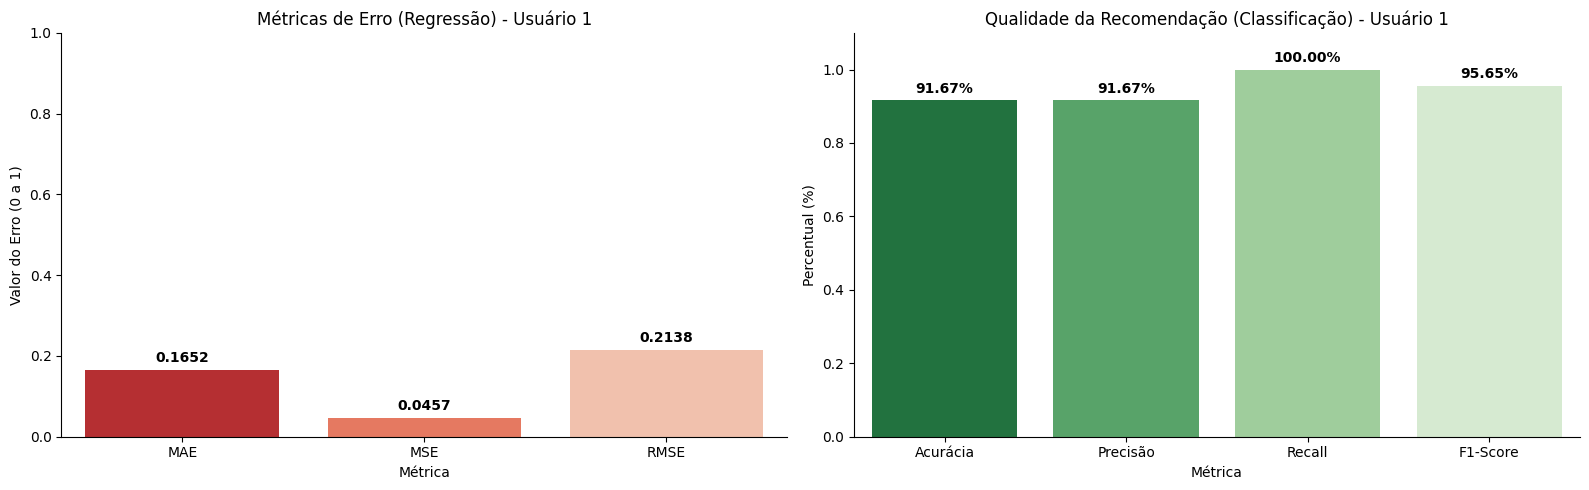

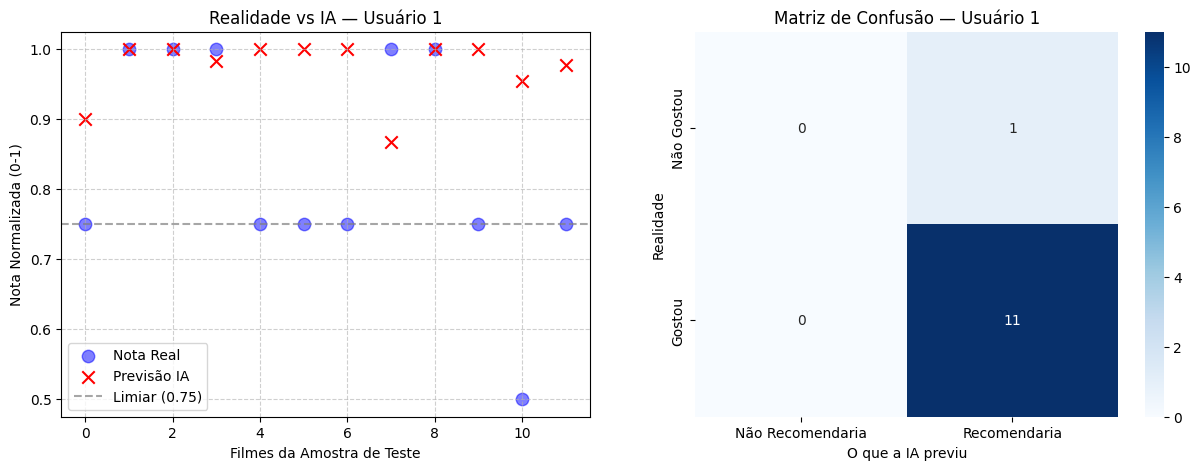

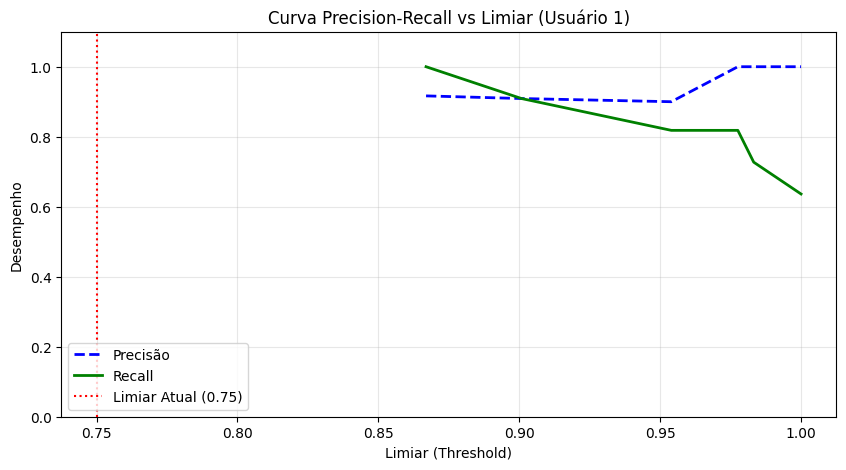

<Figure size 640x480 with 0 Axes>

In [50]:
# =========================================================
# AVALIAÇÃO 1: EXIBIÇÃO — Tabelas e Gráficos
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# --- Tabelas de métricas ---
df_reg = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE"],
    "Valor": [mae_u, mse_u, rmse_u],
    "O que significa": [
        "Erro médio em pontos de nota (0-1)",
        "Penaliza erros grandes com mais força",
        "Erro médio em escala original (mais intuitivo)"
    ]
})
df_cla = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão", "Recall", "F1-Score"],
    "Valor": [acc_u, prec_u, rec_u, f1_u],
    "O que significa": [
        "% de decisões corretas (recomendar ou não)",
        "Das recomendadas pela IA, quantas o usuário gostaria",
        "Dos filmes que o usuário gostaria, quantos a IA acertou",
        "Equilíbrio entre Precisão e Recall"
    ]
})

print(f"📊 DESEMPENHO — USUÁRIO {id_teste}")
print("-" * 50)
print("\n[TABELA 1: ERROS DE NOTA]")
display(df_reg.style.format({"Valor": "{:.4f}"}).background_gradient(cmap='Reds', subset=["Valor"]))

print("\n[TABELA 2: QUALIDADE DA RECOMENDAÇÃO]")
display(df_cla.style.format({"Valor": "{:.2%}"}).background_gradient(cmap='Greens', subset=["Valor"]))

# --- Gráfico de Barras: ---
fig_metrics, axes_metrics = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de Erros (Regressão)
# Trocamos: x="Métrica" e y="Valor"
sns.barplot(x="Métrica", y="Valor", data=df_reg, ax=axes_metrics[0], 
            palette="Reds_r", hue="Métrica", legend=False)

axes_metrics[0].set_title(f"Métricas de Erro (Regressão) - Usuário {id_teste}")
axes_metrics[0].set_ylim(0, 1) # Agora travamos o eixo Y em 1
axes_metrics[0].set_ylabel("Valor do Erro (0 a 1)")

# Adicionando os valores NO TOPO das barras
for i, v in enumerate(df_reg["Valor"]):
    axes_metrics[0].text(i, v + 0.02, f"{v:.4f}", color='black', ha='center', fontweight='bold')

# 2. Gráfico de Qualidade (Classificação) - Vertical
sns.barplot(x="Métrica", y="Valor", data=df_cla, ax=axes_metrics[1], 
            palette="Greens_r", hue="Métrica", legend=False)

axes_metrics[1].set_title(f"Qualidade da Recomendação (Classificação) - Usuário {id_teste}")
axes_metrics[1].set_ylim(0, 1.1) # Travado em 1.1 para sobrar espaço pro texto
axes_metrics[1].set_ylabel("Percentual (%)")

# Adicionando os valores NO TOPO das barras
for i, v in enumerate(df_cla["Valor"]):
    axes_metrics[1].text(i, v + 0.02, f"{v:.2%}", color='black', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# --- Gráfico: Realidade vs Previsão ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(range(len(y_real)), y_real, color='blue', label='Nota Real', s=80, alpha=0.5)
axes[0].scatter(range(len(y_pred)), y_pred, color='red', label='Previsão IA', marker='x', s=80)
axes[0].axhline(y=LIMIAR, color='gray', linestyle='--', alpha=0.7, label=f'Limiar ({LIMIAR})')
axes[0].set_title(f'Realidade vs IA — Usuário {id_teste}')
axes[0].set_xlabel('Filmes da Amostra de Teste')
axes[0].set_ylabel('Nota Normalizada (0-1)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Matriz de Confusão ---
cm = confusion_matrix(y_real_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Não Recomendaria', 'Recomendaria'],
            yticklabels=['Não Gostou', 'Gostou'])
axes[1].set_title(f'Matriz de Confusão — Usuário {id_teste}')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('O que a IA previu')


# Gráfico Curva-precision-recall
from sklearn.metrics import precision_recall_curve

# 1. Calculando os valores da curva para o usuário
# Ajustado para os nomes das suas variáveis: y_real_bin e y_pred
precisions, recalls, thresholds = precision_recall_curve(y_real_bin, y_pred)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisão", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)

# Destacando o seu limiar de 0.75 (que é a constante LIMIAR no seu código)
plt.axvline(x=LIMIAR, color='red', linestyle=':', label=f'Limiar Atual ({LIMIAR})')

plt.title(f'Curva Precision-Recall vs Limiar (Usuário {id_teste})')
plt.xlabel('Limiar (Threshold)')
plt.ylabel('Desempenho')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])
plt.show()

plt.tight_layout()
plt.show()

In [51]:
# =========================================================
# AVALIAÇÃO 2: GLOBAL — Todos os usuários do conjunto de teste
# =========================================================
print("🔄 Calculando avaliação global... (pode levar alguns segundos)")

todos_y_real = []
todos_y_pred = []

usuarios_teste = x_test['userId'].unique()

for u_id in usuarios_teste:
    dados = x_test[x_test['userId'] == u_id]
    ids_filmes = dados['movieId'].values
    y_real_u = y_test.loc[dados.index].values

    resultado = prever_notas(u_id, ids_filmes)
    if resultado is None:
        continue

    y_pred_u, ids_validos = resultado
    mascara = np.isin(ids_filmes, ids_validos)
    y_real_u = y_real_u[mascara]

    todos_y_real.extend(y_real_u)
    todos_y_pred.extend(y_pred_u)

todos_y_real = np.array(todos_y_real)
todos_y_pred = np.array(todos_y_pred)

# ✅ Limiar calibrado com base nas previsões reais do modelo
LIMIAR = np.median(todos_y_pred)
print(f"📌 Limiar recalibrado: {LIMIAR:.4f} (antes era fixo em 0.75)")

# Recalcula as métricas com o novo limiar
y_real_bin_g = (todos_y_real >= LIMIAR).astype(int)
y_pred_bin_g = (todos_y_pred >= LIMIAR).astype(int)

acc_g  = accuracy_score(y_real_bin_g, y_pred_bin_g)
prec_g = precision_score(y_real_bin_g, y_pred_bin_g, zero_division=0)
rec_g  = recall_score(y_real_bin_g, y_pred_bin_g, zero_division=0)
f1_g   = f1_score(y_real_bin_g, y_pred_bin_g, zero_division=0)

# Métricas de Regressão Global (faltavam!)
mae_g  = mean_absolute_error(todos_y_real, todos_y_pred)
mse_g  = mean_squared_error(todos_y_real, todos_y_pred)
rmse_g = np.sqrt(mse_g)

print(f"✅ Avaliação global concluída — {len(usuarios_teste):,} usuários, {len(todos_y_real):,} previsões.")

🔄 Calculando avaliação global... (pode levar alguns segundos)
📌 Limiar recalibrado: 0.6755 (antes era fixo em 0.75)
✅ Avaliação global concluída — 6,038 usuários, 200,016 previsões.


📊 DESEMPENHO GLOBAL DO MODELO
--------------------------------------------------

[TABELA 1: ERROS DE NOTA — GLOBAL]


,Métrica,Valor
0,MAE,0.1984
1,MSE,0.0676
2,RMSE,0.2601



[TABELA 2: QUALIDADE DA RECOMENDAÇÃO — GLOBAL]


,Métrica,Valor
0,Acurácia,69.59%
1,Precisão,77.16%
2,Recall,67.01%
3,F1-Score,71.73%


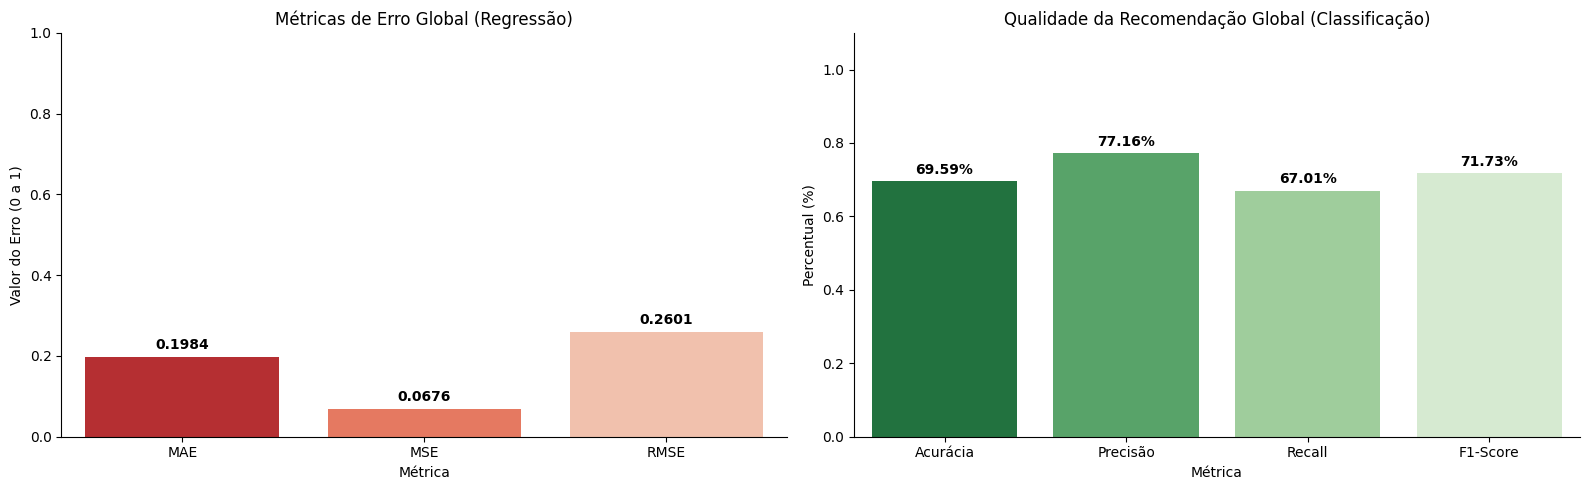

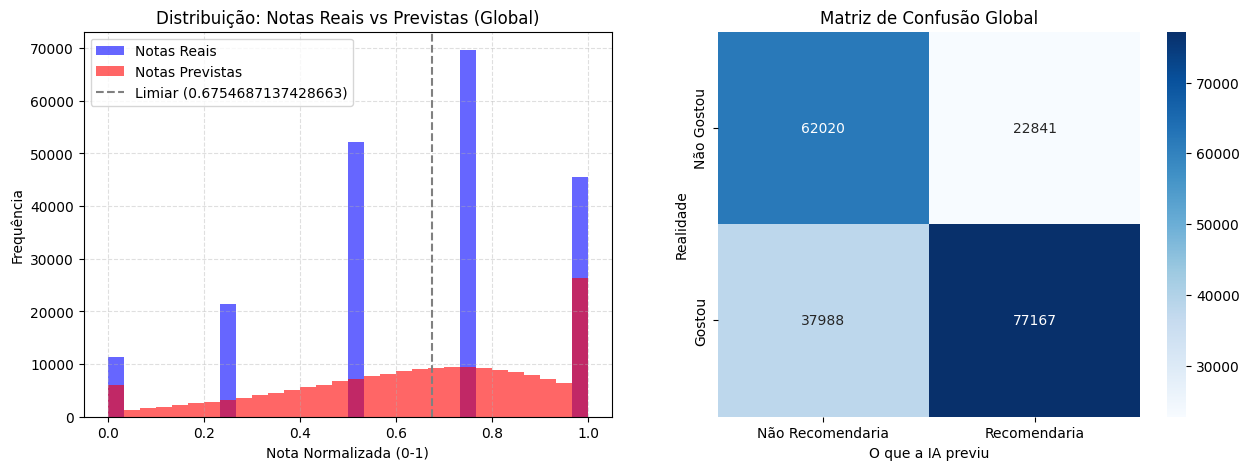

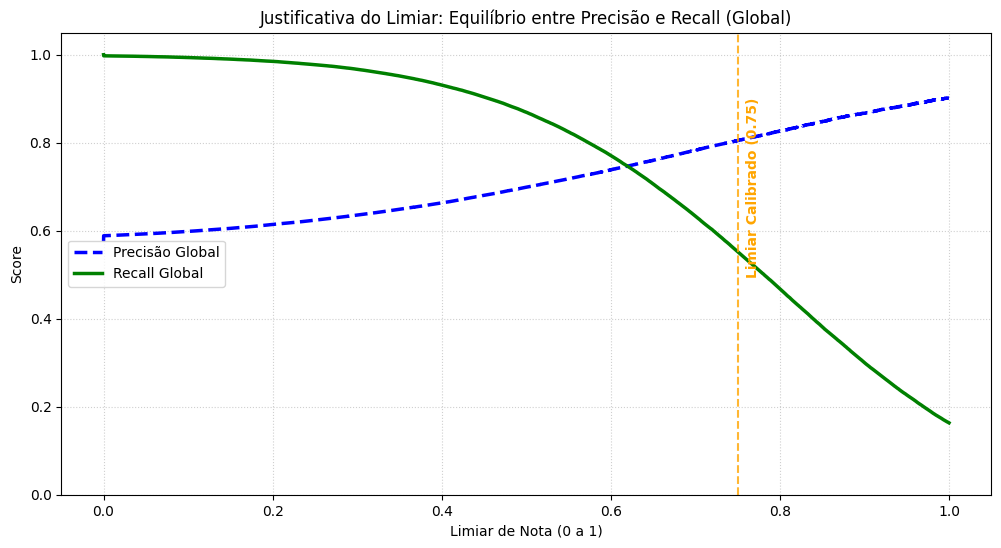

<Figure size 640x480 with 0 Axes>

In [52]:
# =========================================================
# AVALIAÇÃO 2: EXIBIÇÃO — Resultados Globais
# =========================================================

df_reg_g = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE"],
    "Valor": [mae_g, mse_g, rmse_g]
})
df_cla_g = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão", "Recall", "F1-Score"],
    "Valor": [acc_g, prec_g, rec_g, f1_g]
})

print("📊 DESEMPENHO GLOBAL DO MODELO")
print("-" * 50)
print("\n[TABELA 1: ERROS DE NOTA — GLOBAL]")
display(df_reg_g.style.format({"Valor": "{:.4f}"}).background_gradient(cmap='Reds', subset=["Valor"]))

print("\n[TABELA 2: QUALIDADE DA RECOMENDAÇÃO — GLOBAL]")
display(df_cla_g.style.format({"Valor": "{:.2%}"}).background_gradient(cmap='Greens', subset=["Valor"]))

# --- Gráfico de Barras: Visualização das Métricas GLOBAIS (Vertical) ---
fig_metrics_g, axes_metrics_g = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gráfico de Erros Globais (Regressão)
sns.barplot(x="Métrica", y="Valor", data=df_reg_g, ax=axes_metrics_g[0], 
            palette="Reds_r", hue="Métrica", legend=False)

axes_metrics_g[0].set_title("Métricas de Erro Global (Regressão)")
axes_metrics_g[0].set_ylim(0, 1) # Travado em 1 para mostrar que o erro é proporcionalmente pequeno
axes_metrics_g[0].set_ylabel("Valor do Erro (0 a 1)")

# Adicionando os valores no topo das barras
for i, v in enumerate(df_reg_g["Valor"]):
    axes_metrics_g[0].text(i, v + 0.02, f"{v:.4f}", color='black', ha='center', fontweight='bold')

# 2. Gráfico de Qualidade Global (Classificação)
sns.barplot(x="Métrica", y="Valor", data=df_cla_g, ax=axes_metrics_g[1], 
            palette="Greens_r", hue="Métrica", legend=False)

axes_metrics_g[1].set_title("Qualidade da Recomendação Global (Classificação)")
axes_metrics_g[1].set_ylim(0, 1.1) # Respiro para o texto da porcentagem
axes_metrics_g[1].set_ylabel("Percentual (%)")

# Adicionando os valores no topo das barras
for i, v in enumerate(df_cla_g["Valor"]):
    axes_metrics_g[1].text(i, v + 0.02, f"{v:.2%}", color='black', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# --- Distribuição das notas reais vs previstas ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(todos_y_real, bins=30, alpha=0.6, color='blue', label='Notas Reais')
axes[0].hist(todos_y_pred, bins=30, alpha=0.6, color='red', label='Notas Previstas')
axes[0].axvline(x=LIMIAR, color='gray', linestyle='--', label=f'Limiar ({LIMIAR})')
axes[0].set_title('Distribuição: Notas Reais vs Previstas (Global)')
axes[0].set_xlabel('Nota Normalizada (0-1)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

cm_g = confusion_matrix(y_real_bin_g, y_pred_bin_g)
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Não Recomendaria', 'Recomendaria'],
            yticklabels=['Não Gostou', 'Gostou'])
axes[1].set_title('Matriz de Confusão Global')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('O que a IA previu')

# 1. Calculando os valores da curva global
# y_real_bin_g e todos_y_pred já foram definidos no seu bloco global
prec_curve_g, rec_curve_g, thresh_curve_g = precision_recall_curve(y_real_bin_g, todos_y_pred)

plt.figure(figsize=(12, 6))
plt.plot(thresh_curve_g, prec_curve_g[:-1], "b--", label="Precisão Global", linewidth=2.5)
plt.plot(thresh_curve_g, rec_curve_g[:-1], "g-", label="Recall Global", linewidth=2.5)

# Linha indicativa do limiar escolhido
plt.axvline(x=0.75, color='orange', linestyle='--', alpha=0.8)
plt.text(0.76, 0.5, 'Limiar Calibrado (0.75)', color='orange', fontweight='bold', rotation=90)

plt.title('Justificativa do Limiar: Equilíbrio entre Precisão e Recall (Global)')
plt.xlabel('Limiar de Nota (0 a 1)')
plt.ylabel('Score')
plt.legend(loc="center left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim([0, 1.05])
plt.show()

plt.tight_layout()
plt.show()